<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/03_build_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, prepare headless rendering, mount Drive.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "03"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR, TRIPOSR_DIR = "/content/StarX", "/content/TripoSR"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
else:
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS[NOTEBOOK_ID]:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )

# headless rendering: OSMesa system lib for the CPU fallback, and the
# platform choice must be set before pyrender is ever imported
if IN_COLAB:
    subprocess.run(
        ["apt-get", "install", "-y", "-q", "libosmesa6"],
        check=False, capture_output=True,
    )
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: Tesla T4
       vram_gb: 14.6
  disk_free_gb: 65.7
     cpu_count: 2
      in_colab: True


# 03 - Build the training dataset

One pass over every design produces everything training needs, packed into tar shards on Drive:

- the sketch channel stack from notebook 02's rasterizer,
- ground-truth renders of the design's normalized mesh from many viewpoints, with masks and camera matrices.

Before the long build, a hard gate checks that our render cameras agree exactly with TripoSR's own renderer - the one silent failure mode that could poison all supervision.

Use a GPU runtime: the gate runs the pretrained model once, and EGL rendering uses the GPU. The build cells are resumable - re-running this notebook after a disconnect picks up where it stopped.

In [2]:
# Configuration - every tunable for this notebook lives here.
import json
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import trimesh
from PIL import Image
from tqdm.auto import tqdm

from starx import cameras, checkpoint, fusion, rasterize, render_gt, shards, viz
from starx.config import (
    CAMERA_DISTANCE,
    FOVY_DEG,
    SCENE_RADIUS,
    StarXConfig,
    shard_dir,
    stats_dir,
)

SMOKE = False      # True: tiny splits into smoke_train/smoke_test dirs
LIMIT_DESIGNS = 20   # designs per split when SMOKE is on
OVERWRITE = False    # True: rebuild shards even when their marker exists
SEED = 1337
SPLIT_PREFIX = "smoke_" if SMOKE else ""

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
    sketch_size=512,
    supersample=2,
    stroke_width=5,
    stroke_value=0,
    bg_value=128,
    margin=0.05,
    normalization_mode="shared",
    max_sketch_channels=6,
    include_construction=False,
    truncate_extra_sketches=True,
    gt_size=256,
    n_views=16,
    elev_range=(-10.0, 45.0),
    shard_size=200,
    seed=SEED,
)
error_log = Path(cfg.drive_root) / "shards" / f"{SPLIT_PREFIX}errors.jsonl"

# fixed by the pretrained checkpoint - printed, never tuned
print(f"camera distance {CAMERA_DISTANCE}   fovy {FOVY_DEG} deg   scene radius {SCENE_RADIUS}")
print(f"views per design: {cfg.n_views} at {cfg.gt_size}x{cfg.gt_size}")

camera distance 1.9   fovy 40.0 deg   scene radius 0.87
views per design: 16 at 256x256


In [3]:
# Load the split from notebook 01, get the zip local, and index it.
splits_path = stats_dir(cfg) / "splits.json"
assert splits_path.exists(), "splits.json missing - run notebook 01 first"
splits = json.loads(splits_path.read_text())

zip_local_dir = "/content" if IN_COLAB else os.path.join(REPO_DIR, "data")
zip_path = scolab.ensure_zip_local(cfg, local_dir=zip_local_dir)
names = scolab.zip_inventory(zip_path)
json_members = [
    n
    for n in names
    if n.endswith(".json") and "train_test" not in os.path.basename(n).lower()
]
design_ids = sorted(os.path.basename(n)[:-5] for n in json_members)
zip_index = scolab.build_zip_index(names, design_ids)

train_ids = [d for d in splits["train"] if d in zip_index]
test_ids = [d for d in splits["test"] if d in zip_index]
if SMOKE:
    train_ids = train_ids[:LIMIT_DESIGNS]
    test_ids = test_ids[: max(4, LIMIT_DESIGNS // 4)]
print(f"train designs: {len(train_ids)}   test designs: {len(test_ids)}")

copy r1.0.1.zip:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

train designs: 6900   test designs: 1725


renderer backend: egl


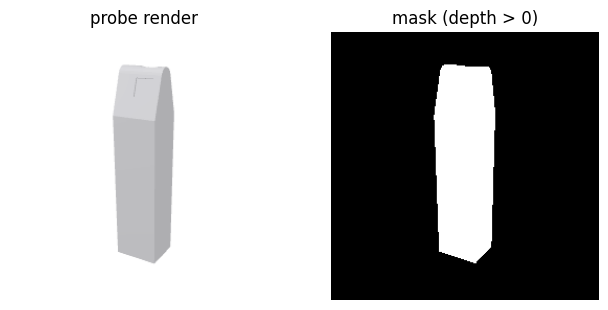

In [4]:
# Start the offscreen renderer and prove it works with one render.
# EGL uses the GPU; if it fails, the OSMesa CPU fallback kicks in
# (correct but slower - the printed backend tells you which you got).
renderer = render_gt.GTRenderer(cfg.gt_size)
print("renderer backend:", renderer.backend)

SAMPLE_ID = "20203_7e31e92a_0000"
if SAMPLE_ID not in zip_index:
    SAMPLE_ID = train_ids[0]
WORK_DIR = Path("/content/work") if IN_COLAB else Path(REPO_DIR) / "data" / "work"
sample_obj_path = scolab.extract_members(
    zip_path, [zip_index[SAMPLE_ID]["obj"]], WORK_DIR
)[0]
sample_png_path = scolab.extract_members(
    zip_path, [zip_index[SAMPLE_ID]["png"]], WORK_DIR
)[0]

raw_mesh = trimesh.load(sample_obj_path, force="mesh")
probe_c2w = cameras.build_spherical_c2w(30.0, 20.0, CAMERA_DISTANCE)
probe_rgb, probe_mask = renderer.render_mesh(
    render_gt.normalize_mesh(raw_mesh)[0], [probe_c2w]
)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
axes[0].imshow(probe_rgb[0])
axes[0].set_title("probe render")
axes[1].imshow(probe_mask[0], cmap="gray")
axes[1].set_title("mask (depth > 0)")
for ax in axes:
    ax.axis("off")
plt.show()

## TripoSR's camera convention

TripoSR was pretrained on objects centered at the origin and scaled to fit a fixed scene sphere, viewed by a perspective camera at a fixed distance and field of view. The model takes no camera as input - it learned to guess the viewpoint - so nothing forces our ground truth to any absolute frame. What matters is internal consistency: our meshes must be normalized the same way, and our render cameras must follow the same geometry, or the rendering loss would compare misaligned images.

Those three numbers (camera distance, field of view, scene radius) are printed by the configuration cell and never tuned: they are properties of the pretrained checkpoint, not hyperparameters.

In [5]:
# Normalize the sample mesh into the scene cube TripoSR expects and show
# it inside a unit-cube wireframe.
norm_mesh, mesh_center, mesh_scale = render_gt.normalize_mesh(raw_mesh)
v = np.asarray(norm_mesh.vertices)
f = np.asarray(norm_mesh.faces)

corner = 0.5
edges = []
c = [-corner, corner]
for a in c:
    for b in c:
        edges += [
            ([-corner, corner], [a, a], [b, b]),
            ([a, a], [-corner, corner], [b, b]),
            ([a, a], [b, b], [-corner, corner]),
        ]
fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v[:, 0], y=v[:, 1], z=v[:, 2],
        i=f[:, 0], j=f[:, 1], k=f[:, 2],
        color="#4c78a8", flatshading=True, name="normalized mesh",
    )
)
for ex, ey, ez in edges:
    fig.add_trace(
        go.Scatter3d(
            x=ex, y=ey, z=ez, mode="lines",
            line=dict(color="#9aa5b1", width=2), showlegend=False,
        )
    )
fig.update_scenes(aspectmode="data")
fig.update_layout(height=460, margin=dict(l=0, r=0, t=30, b=0),
                  title="normalized mesh inside the unit cube")
fig.show()
print(f"original center (cm): {np.round(mesh_center, 2)}")
print(f"scale factor: {mesh_scale:.5f}  -> largest extent now 1.0")

original center (cm): [-2.36  3.   -7.  ]
scale factor: 0.03847  -> largest extent now 1.0


In [6]:
# Where do the ground-truth cameras sit? Deterministic per design (seeded
# by the design id), random azimuth, elevation inside the configured range.
sample_c2ws, sample_angles = cameras.sample_design_views(
    SAMPLE_ID, cfg.n_views, cfg.elev_range, seed=cfg.seed
)
positions = sample_c2ws[:, :3, 3]
verts = np.asarray(norm_mesh.vertices)
verts = verts[:: max(1, len(verts) // 800)]

fig = go.Figure()
fig.add_trace(
    go.Scatter3d(
        x=positions[:, 0], y=positions[:, 1], z=positions[:, 2],
        mode="markers", marker=dict(size=5, color="#f58518"), name="cameras",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        mode="markers", marker=dict(size=1.5, color="#4c78a8"), name="mesh",
    )
)
fig.update_scenes(aspectmode="data")
fig.update_layout(height=460, margin=dict(l=0, r=0, t=30, b=0),
                  title="sampled ground-truth cameras around the part")
fig.show()

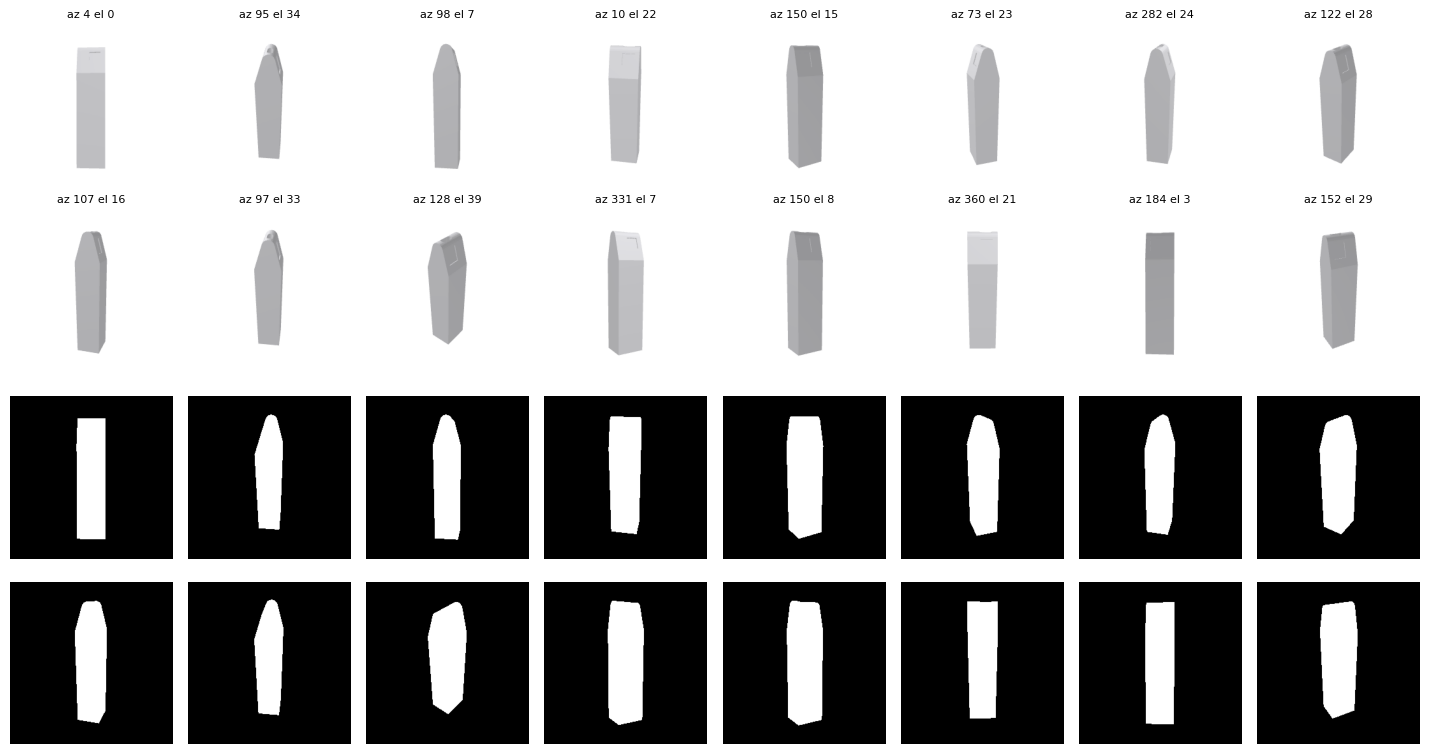

In [7]:
# Render the sample design at all of its sampled cameras: color renders on
# top, the masks (alpha channel of the stored PNGs) below.
sample_rgbs, sample_masks = renderer.render_mesh(norm_mesh, sample_c2ws)
titles = [f"az {a:.0f} el {e:.0f}" for a, e in sample_angles]
fig = viz.show_view_grid(list(sample_rgbs), list(sample_masks), titles=titles)
plt.show()

## The alignment gate

TripoSR predicts shapes in its own canonical camera setup, and training will compare its renders pixel-by-pixel against ours. If our camera convention disagreed with TripoSR's - a flipped axis, a different up direction - every ground-truth image would be silently wrong, training would chase an impossible target, and nothing would error out.

So before any bulk rendering, one test: run the pretrained model on the sample design's thumbnail, render its prediction twice at the same cameras - once with TripoSR's own renderer, once with our pyrender pipeline on the extracted mesh - and require the silhouettes to overlap almost perfectly. Only if that holds do we trust the pipeline with hours of rendering.

loading pretrained TripoSR (first run downloads ~1.7 GB)...


config.yaml:   0%|          | 0.00/987 [00:00<?, ?B/s]

model.ckpt: reconstructing file:   0%|          |  0.00B / 1.68GB            

model.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

/content/TripoSR/tsr/utils.py:376: UserWarning:

Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)



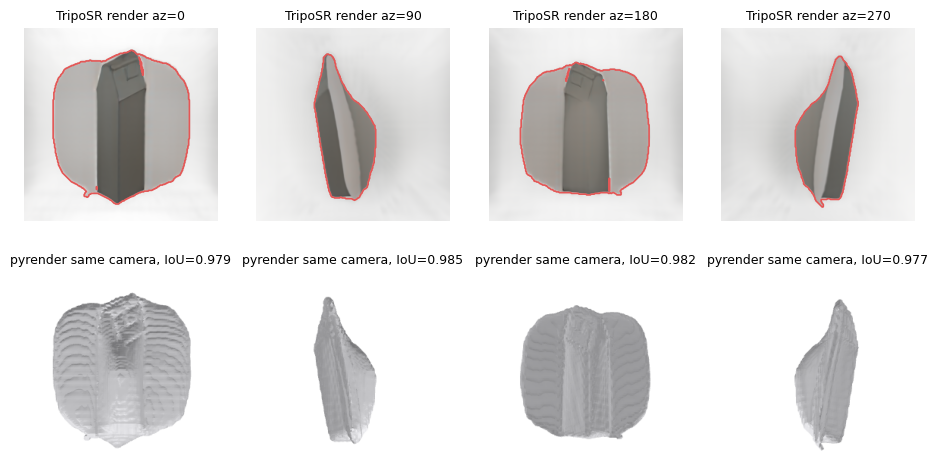

mask IoUs: ['0.979', '0.985', '0.982', '0.977']
alignment gate passed


In [8]:
# The alignment gate: prove our pyrender cameras see exactly what
# TripoSR's own renderer sees, before rendering thousands of designs.
# TripoSR's mask comes from ray-marched opacity, not from color: the
# volume renderer leaves faint fog across the whole scene box, so a
# color threshold would count nearly the entire image as object.
import torch

from starx import eval as seval
from starx import model as smodel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("loading pretrained TripoSR (first run downloads ~1.7 GB)...")
tsr_model = smodel.load_pretrained_tsr(TRIPOSR_DIR, device=device)
tsr_model.renderer.set_chunk_size(cfg.eval_chunk)

thumb = Image.open(sample_png_path).convert("RGB")
with torch.no_grad():
    scene_codes = tsr_model([thumb], device=device)

gate_azimuths = [0.0, 90.0, 180.0, 270.0]
tsr_views = tsr_model.render(
    scene_codes, n_views=4, elevation_deg=0.0,
    height=cfg.gt_size, width=cfg.gt_size, return_type="np",
)[0]
from tsr.utils import get_spherical_cameras

gate_rays_o, gate_rays_d = get_spherical_cameras(
    4, 0.0, CAMERA_DISTANCE, FOVY_DEG, cfg.gt_size, cfg.gt_size
)
pred_mesh = seval.extract_mesh(
    tsr_model, scene_codes[0], res=128, threshold=cfg.mc_threshold
)
assert pred_mesh is not None, "marching cubes found no surface"
gate_c2ws = [
    cameras.build_spherical_c2w(az, 0.0, CAMERA_DISTANCE) for az in gate_azimuths
]
gate_rgbs, gate_masks = renderer.render_mesh(pred_mesh, gate_c2ws)

ious = []
fig, axes = plt.subplots(2, 4, figsize=(11.5, 5.8))
for i in range(4):
    opacity = seval.render_opacity(
        tsr_model, scene_codes[0], gate_rays_o[i], gate_rays_d[i]
    )
    tsr_mask = opacity.cpu().numpy() > 0.5
    overlap = np.logical_and(tsr_mask, gate_masks[i]).sum()
    union = np.logical_or(tsr_mask, gate_masks[i]).sum()
    iou = overlap / max(union, 1)
    ious.append(float(iou))
    axes[0, i].imshow(tsr_views[i])
    axes[0, i].contour(tsr_mask, levels=[0.5], colors=["#e45756"], linewidths=1.2)
    axes[0, i].set_title(f"TripoSR render az={gate_azimuths[i]:.0f}", fontsize=9)
    axes[1, i].imshow(gate_rgbs[i])
    axes[1, i].set_title(f"pyrender same camera, IoU={iou:.3f}", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.show()

print("mask IoUs:", [f"{v:.3f}" for v in ious])
assert min(ious) > 0.9, "camera conventions disagree - DO NOT build the dataset"
del tsr_model, scene_codes
if device == "cuda":
    torch.cuda.empty_cache()
print("alignment gate passed")

## One design, one sample, one resume unit

Drive is extremely slow at many small files, so processed designs are packed into tar shards of a few hundred designs each. Each sample holds four kinds of members: the sketch strip PNG, one RGBA PNG per ground-truth view (color in RGB, mask in alpha), the camera matrices, and a metadata json.

Resume logic is a single rule: a shard exists only when its `.done.json` marker file exists. The marker is written after the tar is fully in place, so an interrupted session leaves no marker and that shard is rebuilt from scratch next run - a few minutes of lost work at most, and never a half-written shard that looks complete.

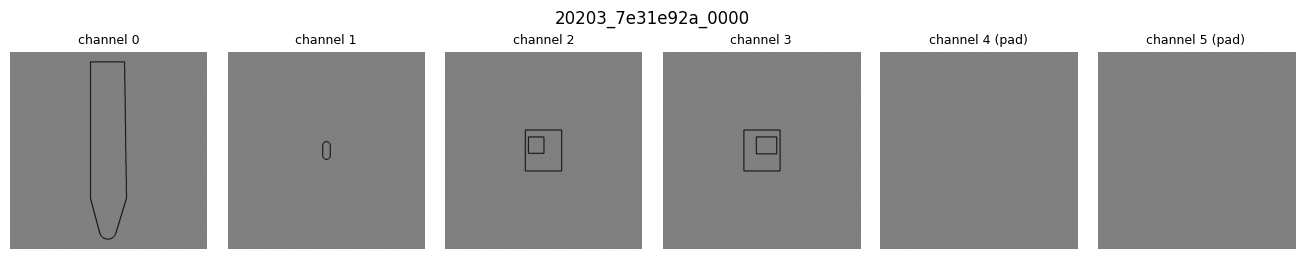

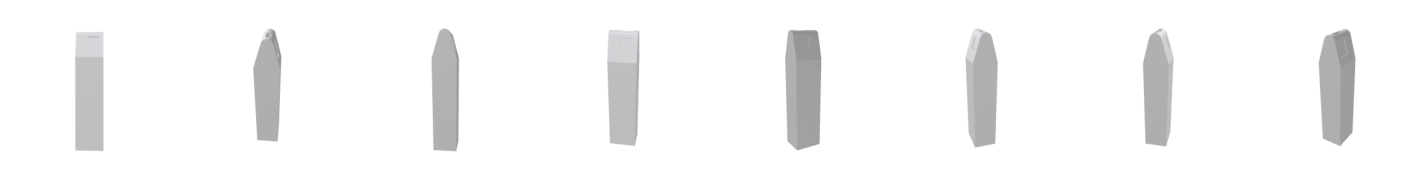

{'split': 'demo', 'mesh_scale': 0.03846853005212667, 'n_views': 16, 'n_channels': 6}


In [9]:
# The per-design worker: json -> sketch stack, obj -> normalized mesh ->
# posed renders, everything encoded as tar members. Demonstrated on the
# sample design, then decoded back to prove the storage roundtrip.
def process_design(design_id, split, zf, renderer):
    """One design -> its tar members (sketch strip, GT views, cameras, meta)."""
    raw = json.load(zf.open(zip_index[design_id]["json"]))
    d = fusion.load_design(raw, design_id=design_id)
    stack_d, meta_d = rasterize.rasterize_design(d, cfg)
    if meta_d["all_blank"]:
        raise ValueError("no drawable sketches")
    obj_member = zip_index[design_id].get("obj")
    if obj_member is None:
        raise ValueError("no mesh")
    obj_path = scolab.extract_members(zip_path, [obj_member], WORK_DIR)[0]
    mesh = trimesh.load(obj_path, force="mesh")
    os.remove(obj_path)
    mesh, center, scale = render_gt.normalize_mesh(mesh)
    c2ws_d, angles_d = cameras.sample_design_views(
        design_id, cfg.n_views, cfg.elev_range, seed=cfg.seed
    )
    rgbs_d, masks_d = renderer.render_mesh(mesh, c2ws_d)
    meta_d.update(
        {
            "split": split,
            "mesh_center_cm": [float(x) for x in center],
            "mesh_scale": float(scale),
            "view_angles": [[float(a), float(e)] for a, e in angles_d],
        }
    )
    return shards.encode_sample(design_id, stack_d, rgbs_d, masks_d, c2ws_d, meta_d)


with zipfile.ZipFile(zip_path) as zf:
    demo_members = process_design(SAMPLE_ID, "demo", zf, renderer)
demo = shards.decode_sample(dict(demo_members))
fig = viz.show_sketch_stack(demo["stack"], demo["meta"], title=demo["design_id"])
plt.show()
fig = viz.show_view_grid(list(demo["views"][:8]))
plt.show()
print({k: demo["meta"][k] for k in ("split", "mesh_scale", "n_views", "n_channels")})

smoke shards:   0%|          | 0/1 [00:00<?, ?it/s]

smoke: 1/1 shards done


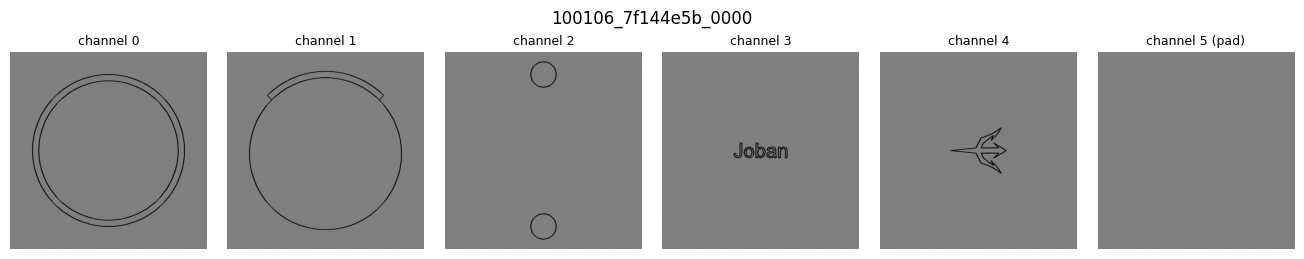

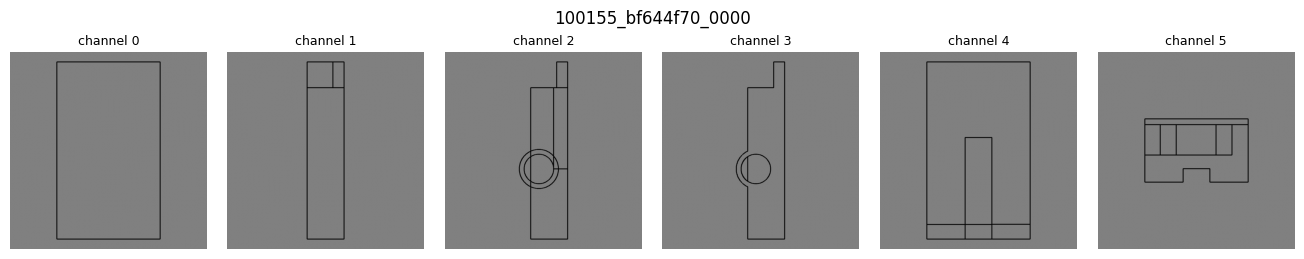

In [10]:
# The shard builder, smoke-tested on a handful of designs end to end
# before committing to the full run.
def build_split(split, ids):
    """Build all shards for one split. A shard only counts once its done-
    marker exists, so re-running skips finished work and resumes cleanly."""
    out_dir = shard_dir(cfg, split)
    chunks = [ids[i : i + cfg.shard_size] for i in range(0, len(ids), cfg.shard_size)]
    for index, chunk in enumerate(tqdm(chunks, desc=f"{split} shards")):
        final_tar = out_dir / shards.shard_name(index)
        if shards.marker_path(final_tar).exists() and not OVERWRITE:
            continue
        writer = shards.ShardWriter(out_dir, index)
        with zipfile.ZipFile(zip_path) as zf:
            for design_id in tqdm(chunk, desc=f"shard {index}", leave=False):
                try:
                    writer.add(process_design(design_id, split, zf, renderer))
                except Exception as error:
                    checkpoint.append_log(
                        error_log,
                        {"design_id": design_id, "split": split, "error": repr(error)},
                    )
        writer.close()
    done = shards.list_done_shards(out_dir)
    print(f"{split}: {len(done)}/{len(chunks)} shards done")


build_split("smoke", train_ids[:20])
smoke_tars = shards.list_done_shards(shard_dir(cfg, "smoke"))
for i, sample in enumerate(shards.iter_shard(smoke_tars[0])):
    if i >= 2:
        break
    fig = viz.show_sketch_stack(sample["stack"], sample["meta"], title=sample["design_id"])
    plt.show()

In [11]:
# Build the train split. This is the long cell (hours for the full set):
# it survives disconnects - finished shards are skipped on re-run, so just
# run the notebook again to resume where it stopped.
build_split(f"{SPLIT_PREFIX}train", train_ids)

train shards:   0%|          | 0/35 [00:00<?, ?it/s]

shard 0:   0%|          | 0/200 [00:00<?, ?it/s]

shard 1:   0%|          | 0/200 [00:00<?, ?it/s]

shard 2:   0%|          | 0/200 [00:00<?, ?it/s]

shard 3:   0%|          | 0/200 [00:00<?, ?it/s]

...

shard 31:   0%|          | 0/200 [00:00<?, ?it/s]

shard 32:   0%|          | 0/200 [00:00<?, ?it/s]

shard 33:   0%|          | 0/200 [00:00<?, ?it/s]

shard 34:   0%|          | 0/100 [00:00<?, ?it/s]

train: 35/35 shards done


In [12]:
# Build the test split the same way.
build_split(f"{SPLIT_PREFIX}test", test_ids)

test shards:   0%|          | 0/9 [00:00<?, ?it/s]

shard 0:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Build report: shard completion, sizes on Drive, and what failed.
report_rows = []
for split, ids in ((f"{SPLIT_PREFIX}train", train_ids), (f"{SPLIT_PREFIX}test", test_ids)):
    done = shards.list_done_shards(shard_dir(cfg, split))
    expected = int(np.ceil(len(ids) / cfg.shard_size))
    total_gb = sum(p.stat().st_size for p in done) / 2**30
    report_rows.append(
        {"split": split, "shards done": len(done), "expected": expected,
         "size GiB": round(total_gb, 2)}
    )
display(pd.DataFrame(report_rows))

errors_df = checkpoint.read_log(error_log)
if errors_df.empty:
    print("no per-design failures logged")
else:
    print(f"{len(errors_df)} designs failed:")
    display(errors_df["error"].value_counts().head(10))

sizes = [
    p.stat().st_size / 2**20
    for p in shards.list_done_shards(shard_dir(cfg, f"{SPLIT_PREFIX}train"))
]
if sizes:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(range(len(sizes)), sizes, color=plt.get_cmap("tab10").colors[0])
    ax.set_xlabel("shard index")
    ax.set_ylabel("MiB")
    ax.set_title("train shard sizes")
    plt.show()

In [ ]:
# Random quality check: pull a few finished samples straight off Drive and
# eyeball them - sketches on the left of the pipeline, renders on the right.
rng = random.Random(SEED)
done_train = shards.list_done_shards(shard_dir(cfg, f"{SPLIT_PREFIX}train"))
qa_samples = []
for tar in rng.sample(done_train, min(3, len(done_train))):
    shard_samples = list(shards.iter_shard(tar))
    qa_samples.extend(rng.sample(shard_samples, min(2, len(shard_samples))))

for sample in qa_samples[:6]:
    fig = viz.show_sketch_stack(
        sample["stack"], sample["meta"], title=sample["design_id"]
    )
    plt.show()
    fig = viz.show_view_grid(list(sample["views"][:8]))
    plt.show()

## Takeaways

The processed dataset now lives on Drive as tar shards: for every design, the sketch-channel strip, posed ground-truth renders with masks, the cameras that produced them, and metadata. The alignment gate proved those cameras agree with TripoSR's own renderer, so the renders are valid supervision targets.

Notebook 04 performs the model surgery: teaching a pretrained TripoSR to accept sketch stacks instead of photographs.